# Metadata-Assisted Multi-Level Classification of News Videos

### Research Internship Project

**Objective:** Develop a metadata-based baseline model to classify news videos across multiple dimensions:
- Content Format
- Source Type
- Language
- Geography
- Production

This notebook implements the complete metadata extraction, preprocessing, feature engineering, model training and evaluation pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive

from googleapiclient.discovery import build

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/News Video Classification")

ANNOTATION_FILE = PROJECT_DIR / "NewsVideoDataset.xlsx"
METADATA_FILE = PROJECT_DIR / "metadata_dataset.csv"
PREDICTION_FILE = PROJECT_DIR / "prediction_results.csv"
CONFUSION_MATRIX_FILE = PROJECT_DIR / "confusion_matrix.png"
MODEL_FILE = PROJECT_DIR / "logistic_regression_geography.pkl"

In [4]:
annotations = pd.read_excel(ANNOTATION_FILE)

print("Dataset loaded successfully!")
print("Shape:", annotations.shape)

annotations.head()

Dataset loaded successfully!
Shape: (150, 8)


,Video_ID,YouTube_Link,Content_Format,Source_Type,Primary_Language,Geography,Production,Notes
0,V001,https://www.youtube.com/live/FdKoMzcZws0?si=hs...,debate,mainstream_media,english,india-national,studio_produced,NaN
1,V002,https://youtu.be/zYmQctYXIeM?si=WCs9GiLW_111mFh2,interview,mainstream_media,english,global,studio_produced,NaN
2,V003,https://youtu.be/Txhtxb0ZjVk?si=w0zAkXwd-aB_d19B,documentary,mainstream_media,english,bangladesh,field-report,NaN
3,V004,https://youtu.be/nx-mGN2Fz5M?si=NR_8s_Ajy5ouH8Yl,explainer,independent_creator,hindi,india-national,studio_produced,NaN
4,V005,https://youtu.be/yUuV3sknWQ0?si=MNevN256P6J6vUHq,analysis,mainstream_media,english,global,studio_produced,NaN


In [5]:
print("Columns:")
print(annotations.columns.tolist())

print("\nMissing values:")
print(annotations.isnull().sum())

Columns:
['Video_ID', 'YouTube_Link', 'Content_Format', 'Source_Type', 'Primary_Language', 'Geography', 'Production', 'Notes']

Missing values:
Video_ID              0
YouTube_Link          0
Content_Format        0
Source_Type           0
Primary_Language      0
Geography             0
Production            0
Notes               139
dtype: int64


In [6]:
print("Total videos:", len(annotations))

print("\nContent Format Distribution:")
print(annotations["Content_Format"].value_counts())

print("\nSource Type Distribution:")
print(annotations["Source_Type"].value_counts())

print("\nPrimary Language Distribution:")
print(annotations["Primary_Language"].value_counts())

print("\nGeography Distribution:")
print(annotations["Geography"].value_counts())

print("\nProduction Distribution:")
print(annotations["Production"].value_counts())

Total videos: 150

Content Format Distribution:
Content_Format
explainer           26
news_bulletin       25
interview           16
press_conference    13
breaking_news       13
fact_check          12
analysis            11
panel_discussion     9
documentary          9
debate               6
podcast_clip         6
reaction_video       2
vlog                 2
Name: count, dtype: int64

Source Type Distribution:
Source_Type
mainstream_media       112
independent_creator     32
citizen_journalism       6
Name: count, dtype: int64

Primary Language Distribution:
Primary_Language
english    104
hindi       43
bengali      3
Name: count, dtype: int64

Geography Distribution:
Geography
india-national         76
global                 62
south_asia_regional     8
bangladesh              4
Name: count, dtype: int64

Production Distribution:
Production
studio_produced    95
field-report       40
archive_footage    15
Name: count, dtype: int64


## Configure YouTube Data API

In [7]:
from google.colab import userdata
from googleapiclient.discovery import build

API_KEY = userdata.get("YOUTUBE_API_KEY")

youtube = build(
    "youtube",
    "v3",
    developerKey=API_KEY
)

print("✅ YouTube API connected successfully!")

✅ YouTube API connected successfully!


## Metadata Extraction Function

In [8]:
import re

def extract_video_id(url):
    """
    Extract YouTube video ID from different YouTube URL formats.
    """

    patterns = [
        r"v=([A-Za-z0-9_-]{11})",
        r"youtu\.be/([A-Za-z0-9_-]{11})",
        r"shorts/([A-Za-z0-9_-]{11})",
        r"live/([A-Za-z0-9_-]{11})"
    ]

    for pattern in patterns:
        match = re.search(pattern, url)
        if match:
            return match.group(1)

    return None

In [9]:
video_id = extract_video_id(
    annotations.loc[0, "YouTube_Link"]
)

print(video_id)

FdKoMzcZws0


In [10]:
def get_video_metadata(video_id):
    """
    Fetch metadata from YouTube Data API.
    """

    request = youtube.videos().list(
        part="snippet,statistics,contentDetails",
        id=video_id
    )

    response = request.execute()

    if len(response["items"]) == 0:
        return None

    item = response["items"][0]

    snippet = item["snippet"]
    stats = item.get("statistics", {})
    content = item.get("contentDetails", {})

    return {
        "title": snippet.get("title"),
        "description": snippet.get("description"),
        "channel": snippet.get("channelTitle"),
        "upload_date": snippet.get("publishedAt"),
        "tags": ", ".join(snippet.get("tags", [])),
        "views": stats.get("viewCount"),
        "likes": stats.get("likeCount"),
        "duration": content.get("duration")
    }

## Metadata Extraction

In [11]:
metadata = []

total = len(annotations)

for idx, row in annotations.iterrows():

    print(f"Processing {idx+1}/{total}...")

    video_id = extract_video_id(row["YouTube_Link"])

    if video_id is None:
        print("❌ Invalid URL")
        continue

    try:

        info = get_video_metadata(video_id)

        if info is None:
            print("⚠️ Video unavailable")
            continue

        info["Video_ID"] = row["Video_ID"]

        metadata.append(info)

    except Exception as e:

        print(f"Error: {e}")

print("\n✅ Metadata extraction completed!")

Processing 1/150...
Processing 2/150...
Processing 3/150...
Processing 4/150...
Processing 5/150...
Processing 6/150...
Processing 7/150...
Processing 8/150...
Processing 9/150...
Processing 10/150...
Processing 11/150...
Processing 12/150...
Processing 13/150...
Processing 14/150...
Processing 15/150...
Processing 16/150...
Processing 17/150...
Processing 18/150...
Processing 19/150...
Processing 20/150...
Processing 21/150...
Processing 22/150...
Processing 23/150...
Processing 24/150...
Processing 25/150...
Processing 26/150...
Processing 27/150...
Processing 28/150...
Processing 29/150...
Processing 30/150...
Processing 31/150...
Processing 32/150...
Processing 33/150...
⚠️ Video unavailable
Processing 34/150...
Processing 35/150...
Processing 36/150...
Processing 37/150...
Processing 38/150...
Processing 39/150...
Processing 40/150...
Processing 41/150...
Processing 42/150...
Processing 43/150...
Processing 44/150...
Processing 45/150...
Processing 46/150...
Processing 47/150...
P

## Create Metadata DataFrame

In [12]:
metadata_df = pd.DataFrame(metadata)

print("Shape:", metadata_df.shape)

metadata_df.head()

Shape: (147, 9)


,title,description,channel,upload_date,tags,views,likes,duration,Video_ID
0,"Debate With Arnab LIVE: 362 MPs With NDA, Is I...","Debate With Arnab LIVE: 362 MPs With NDA, Is I...",Republic World,2026-06-26T15:51:49Z,"UCC debate, Uniform Civil Code, Debate With Ar...",19768,None,PT1H24M35S,V001
1,Full interview: Trump says Iran ‘is not an end...,"In an exclusive interview with Meet the Press,...",NBC News,2026-06-07T18:02:11Z,"dc, election, government, meet the press, mtp,...",1112622,12809,PT39M38S,V002
2,The Mother and the Monster: After Sheikh Hasin...,বাংলা সাবটাইটেল দেখতে উপরে ক্লিক করুন \n\nEnfo...,Al Jazeera English,2025-05-01T11:30:32Z,"Sheikh Hasina, bangladesh, muhammad yunus, ind...",1983906,62548,PT48M46S,V003
3,Reality of Khan Sir | Who is Really After Him?...,🎥 Join the YouTube Course: https://academy.dh...,Dhruv Rathee,2026-06-13T17:25:34Z,"Dhruv Rathee, Dhruv, Rathee, Dhruv Rathee late...",20097196,977508,PT15M13S,V004
4,Iran is using Vietnam-style tactics against th...,"Kenneth Katzman, a Senior Fellow at the The So...",Al Jazeera English,2026-03-13T01:34:13Z,"Al Jazeera analysis, Aljazeera, Hormuz shippin...",163896,1233,PT4M42S,V005


In [13]:
dataset = annotations.merge(
    metadata_df,
    on="Video_ID",
    how="inner"
)

print(dataset.shape)

dataset.head()

(147, 16)


,Video_ID,YouTube_Link,Content_Format,Source_Type,Primary_Language,Geography,Production,Notes,title,description,channel,upload_date,tags,views,likes,duration
0,V001,https://www.youtube.com/live/FdKoMzcZws0?si=hs...,debate,mainstream_media,english,india-national,studio_produced,NaN,"Debate With Arnab LIVE: 362 MPs With NDA, Is I...","Debate With Arnab LIVE: 362 MPs With NDA, Is I...",Republic World,2026-06-26T15:51:49Z,"UCC debate, Uniform Civil Code, Debate With Ar...",19768,None,PT1H24M35S
1,V002,https://youtu.be/zYmQctYXIeM?si=WCs9GiLW_111mFh2,interview,mainstream_media,english,global,studio_produced,NaN,Full interview: Trump says Iran ‘is not an end...,"In an exclusive interview with Meet the Press,...",NBC News,2026-06-07T18:02:11Z,"dc, election, government, meet the press, mtp,...",1112622,12809,PT39M38S
2,V003,https://youtu.be/Txhtxb0ZjVk?si=w0zAkXwd-aB_d19B,documentary,mainstream_media,english,bangladesh,field-report,NaN,The Mother and the Monster: After Sheikh Hasin...,বাংলা সাবটাইটেল দেখতে উপরে ক্লিক করুন \n\nEnfo...,Al Jazeera English,2025-05-01T11:30:32Z,"Sheikh Hasina, bangladesh, muhammad yunus, ind...",1983906,62548,PT48M46S
3,V004,https://youtu.be/nx-mGN2Fz5M?si=NR_8s_Ajy5ouH8Yl,explainer,independent_creator,hindi,india-national,studio_produced,NaN,Reality of Khan Sir | Who is Really After Him?...,🎥 Join the YouTube Course: https://academy.dh...,Dhruv Rathee,2026-06-13T17:25:34Z,"Dhruv Rathee, Dhruv, Rathee, Dhruv Rathee late...",20097196,977508,PT15M13S
4,V005,https://youtu.be/yUuV3sknWQ0?si=MNevN256P6J6vUHq,analysis,mainstream_media,english,global,studio_produced,NaN,Iran is using Vietnam-style tactics against th...,"Kenneth Katzman, a Senior Fellow at the The So...",Al Jazeera English,2026-03-13T01:34:13Z,"Al Jazeera analysis, Aljazeera, Hormuz shippin...",163896,1233,PT4M42S


In [14]:
dataset.to_csv(
    METADATA_FILE,
    index=False
)

print("✅ Dataset saved successfully!")

✅ Dataset saved successfully!


In [15]:
dataset.isnull().sum()

,0
Video_ID,0
YouTube_Link,0
Content_Format,0
Source_Type,0
Primary_Language,0
Geography,0
Production,0
Notes,136
title,0
description,0


In [16]:
dataset.fillna("", inplace=True)

dataset.isnull().sum()

,0
Video_ID,0
YouTube_Link,0
Content_Format,0
Source_Type,0
Primary_Language,0
Geography,0
Production,0
Notes,0
title,0
description,0


In [17]:
dataset.shape

(147, 16)

In [18]:
dataset.isnull().sum()

,0
Video_ID,0
YouTube_Link,0
Content_Format,0
Source_Type,0
Primary_Language,0
Geography,0
Production,0
Notes,0
title,0
description,0


## Data Cleaning

In [19]:
# Replace missing text values with empty strings
text_columns = [
    "title",
    "description",
    "tags",
    "channel",
    "Notes"
]

for col in text_columns:
    dataset[col] = dataset[col].fillna("")

# Replace missing numeric values
dataset["likes"] = dataset["likes"].fillna(0)
dataset["views"] = dataset["views"].fillna(0)

print(dataset.isnull().sum())

Video_ID            0
YouTube_Link        0
Content_Format      0
Source_Type         0
Primary_Language    0
Geography           0
Production          0
Notes               0
title               0
description         0
channel             0
upload_date         0
tags                0
views               0
likes               0
duration            0
dtype: int64


## Feature Engineering

In [20]:
dataset["text"] = (
    dataset["title"] + " " +
    dataset["description"] + " " +
    dataset["tags"] + " " +
    dataset["channel"]
)

In [21]:
dataset[["Video_ID", "text"]].head()

,Video_ID,text
0,V001,"Debate With Arnab LIVE: 362 MPs With NDA, Is I..."
1,V002,Full interview: Trump says Iran ‘is not an end...
2,V003,The Mother and the Monster: After Sheikh Hasin...
3,V004,Reality of Khan Sir | Who is Really After Him?...
4,V005,Iran is using Vietnam-style tactics against th...


## TF-IDF Vectorization

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=5000
)

X = vectorizer.fit_transform(dataset["text"])

print(X.shape)

(147, 5000)


In [23]:
y = dataset["Geography"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(117, 5000)
(30, 5000)


In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


## Cross Validation

In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage Accuracy: {:.2f}%".format(scores.mean()*100))

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Cross Validation Scores:
[0.73333333 0.76666667 0.82758621 0.86206897 0.79310345]

Average Accuracy: 79.66%


## Predictions

In [27]:
y_pred = model.predict(X_test)

## Classification Report

In [28]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

                     precision    recall  f1-score   support

         bangladesh       0.00      0.00      0.00         1
             global       0.85      0.92      0.88        12
     india-national       0.88      1.00      0.94        15
south_asia_regional       0.00      0.00      0.00         2

           accuracy                           0.87        30
          macro avg       0.43      0.48      0.45        30
       weighted avg       0.78      0.87      0.82        30



## Confusion Matrix

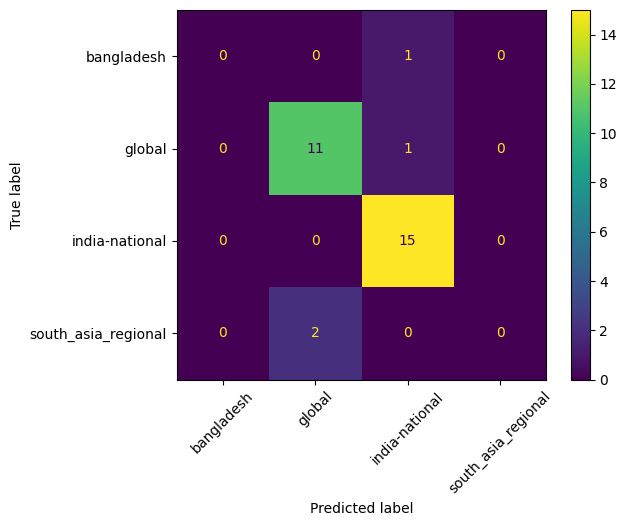

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = sorted(dataset["Geography"].unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    xticks_rotation=45
)

plt.show()

## Save Results

In [30]:
results = pd.DataFrame({

    "Actual": y_test.values,
    "Predicted": y_pred

})

results.to_csv(
    PREDICTION_FILE,
    index=False
)

print(results.head())

           Actual       Predicted
0  india-national  india-national
1  india-national  india-national
2  india-national  india-national
3  india-national  india-national
4          global          global


<Figure size 600x600 with 0 Axes>

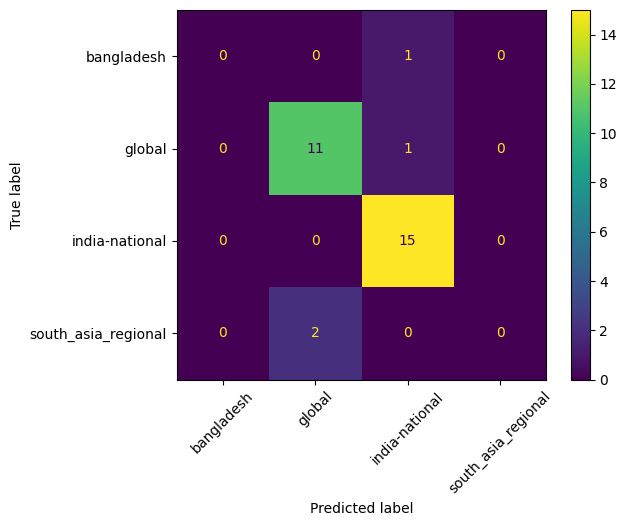

In [31]:
plt.figure(figsize=(6,6))

disp.plot(
    xticks_rotation=45
)

plt.savefig(
    CONFUSION_MATRIX_FILE,
    bbox_inches="tight"
)

plt.show()

In [32]:
import joblib

joblib.dump(
    model,
    MODEL_FILE
)

print("✅ Model saved successfully!")

✅ Model saved successfully!


# Universal Training Function

In [33]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
import matplotlib.pyplot as plt

def run_experiment(target_column, model, model_name):

    print("="*60)
    print(f"Model: {model_name}")
    print(f"Target: {target_column}")
    print("="*60)

    y = dataset[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model.fit(X_train, y_train)

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    y_pred = model.predict(X_test)

    print("\nCross Validation Scores:")
    print(scores)

    print("\nAverage CV Accuracy: {:.2f}%".format(scores.mean()*100))

    print("\nTest Accuracy: {:.2f}%".format(
        accuracy_score(y_test, y_pred)*100
    ))

    print("\nClassification Report:\n")
    print(classification_report(
        y_test,
        y_pred,
        zero_division=0
    ))

    labels = sorted(dataset[target_column].unique())

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=labels
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(xticks_rotation=45)

    plt.show()

    return scores.mean(), accuracy_score(y_test, y_pred)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [35]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        random_state=42
    ),

    "Naive Bayes": MultinomialNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

Model: Logistic Regression
Target: Geography


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



Cross Validation Scores:
[0.73333333 0.76666667 0.82758621 0.86206897 0.79310345]

Average CV Accuracy: 79.66%

Test Accuracy: 86.67%

Classification Report:

                     precision    recall  f1-score   support

         bangladesh       0.00      0.00      0.00         1
             global       0.85      0.92      0.88        12
     india-national       0.88      1.00      0.94        15
south_asia_regional       0.00      0.00      0.00         2

           accuracy                           0.87        30
          macro avg       0.43      0.48      0.45        30
       weighted avg       0.78      0.87      0.82        30



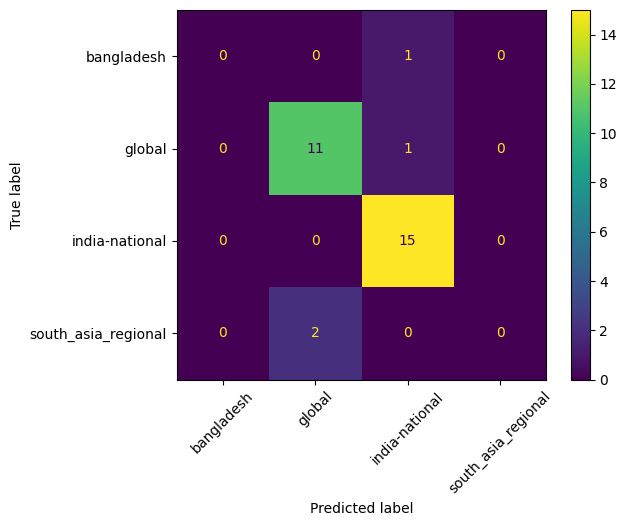

Model: Linear SVM
Target: Geography

Cross Validation Scores:
[0.76666667 0.8        0.82758621 0.89655172 0.79310345]

Average CV Accuracy: 81.68%

Test Accuracy: 86.67%

Classification Report:

                     precision    recall  f1-score   support

         bangladesh       0.00      0.00      0.00         1
             global       0.85      0.92      0.88        12
     india-national       0.88      1.00      0.94        15
south_asia_regional       0.00      0.00      0.00         2

           accuracy                           0.87        30
          macro avg       0.43      0.48      0.45        30
       weighted avg       0.78      0.87      0.82        30



/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


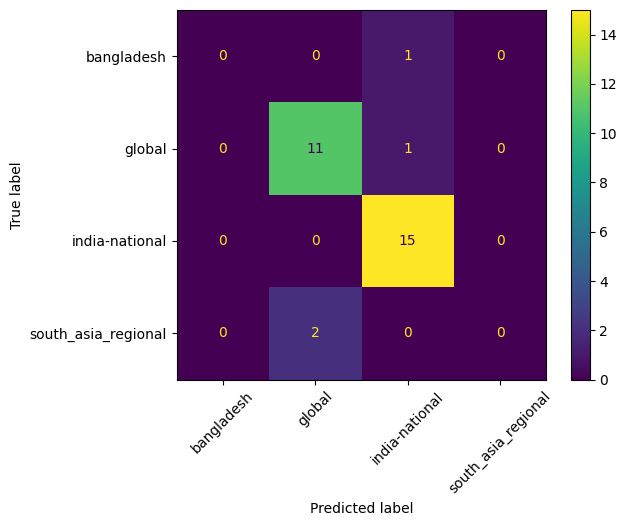

Model: Naive Bayes
Target: Geography

Cross Validation Scores:
[0.76666667 0.73333333 0.82758621 0.79310345 0.79310345]

Average CV Accuracy: 78.28%

Test Accuracy: 83.33%

Classification Report:

                     precision    recall  f1-score   support

         bangladesh       0.00      0.00      0.00         1
             global       0.91      0.83      0.87        12
     india-national       0.79      1.00      0.88        15
south_asia_regional       0.00      0.00      0.00         2

           accuracy                           0.83        30
          macro avg       0.42      0.46      0.44        30
       weighted avg       0.76      0.83      0.79        30



/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


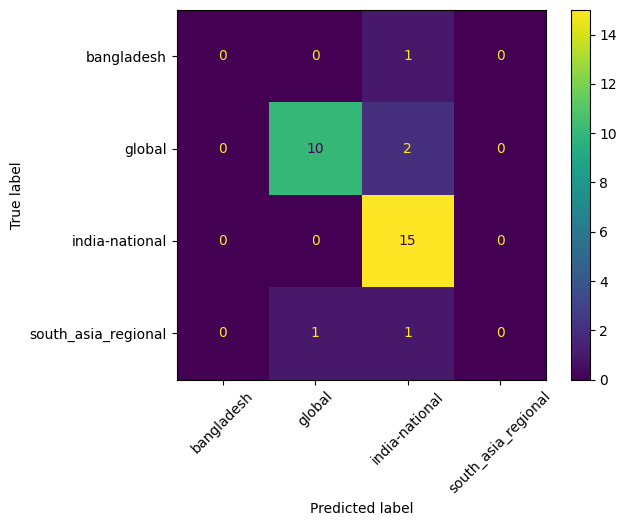

Model: Random Forest
Target: Geography


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(



Cross Validation Scores:
[0.66666667 0.63333333 0.89655172 0.79310345 0.86206897]

Average CV Accuracy: 77.03%

Test Accuracy: 90.00%

Classification Report:

                     precision    recall  f1-score   support

         bangladesh       0.00      0.00      0.00         1
             global       0.86      1.00      0.92        12
     india-national       0.94      1.00      0.97        15
south_asia_regional       0.00      0.00      0.00         2

           accuracy                           0.90        30
          macro avg       0.45      0.50      0.47        30
       weighted avg       0.81      0.90      0.85        30



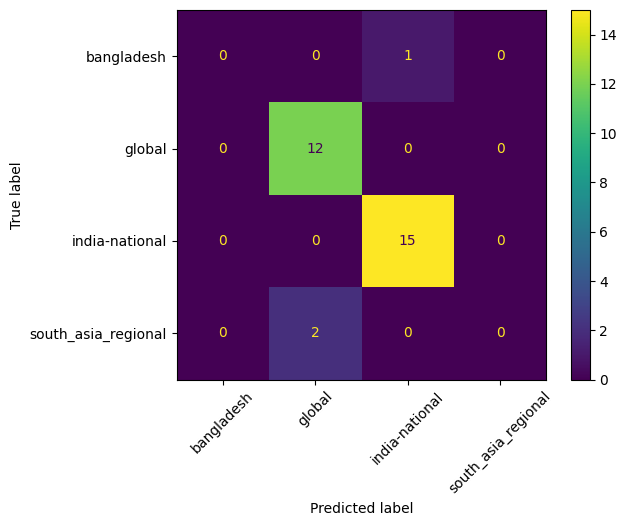

Model: Decision Tree
Target: Geography

Cross Validation Scores:
[0.56666667 0.43333333 0.48275862 0.44827586 0.75862069]

Average CV Accuracy: 53.79%

Test Accuracy: 63.33%

Classification Report:



/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


                     precision    recall  f1-score   support

         bangladesh       0.00      0.00      0.00         1
             global       0.73      0.67      0.70        12
     india-national       0.65      0.73      0.69        15
south_asia_regional       0.00      0.00      0.00         2

           accuracy                           0.63        30
          macro avg       0.34      0.35      0.35        30
       weighted avg       0.61      0.63      0.62        30



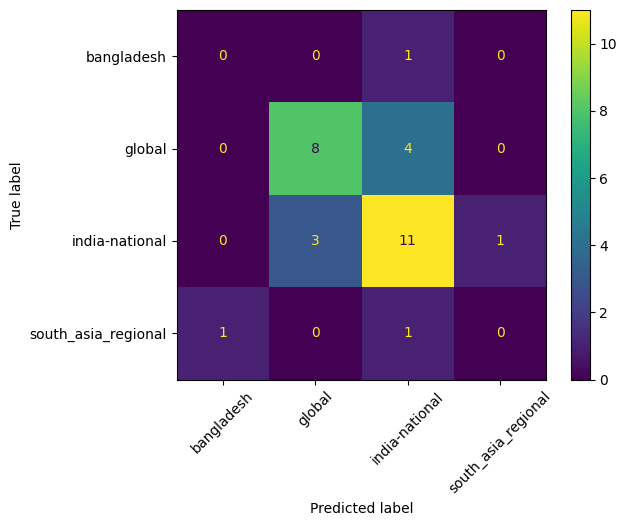

In [36]:
results = []

for name, model in models.items():

    cv_acc, test_acc = run_experiment(
        "Geography",
        model,
        name
    )

    results.append([
        name,
        cv_acc,
        test_acc
    ])

In [37]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "CV Accuracy",
        "Test Accuracy"
    ]
)

results_df["CV Accuracy"] *= 100
results_df["Test Accuracy"] *= 100

results_df

,Model,CV Accuracy,Test Accuracy
0,Logistic Regression,79.655172,86.666667
1,Linear SVM,81.678161,86.666667
2,Naive Bayes,78.275862,83.333333
3,Random Forest,77.034483,90.000000
4,Decision Tree,53.793103,63.333333


Model: Logistic Regression
Target: Primary_Language


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



Cross Validation Scores:
[0.7        0.73333333 0.75862069 0.72413793 0.72413793]

Average CV Accuracy: 72.80%

Test Accuracy: 76.67%

Classification Report:

              precision    recall  f1-score   support

     bengali       0.00      0.00      0.00         1
     english       0.75      1.00      0.86        21
       hindi       1.00      0.25      0.40         8

    accuracy                           0.77        30
   macro avg       0.58      0.42      0.42        30
weighted avg       0.79      0.77      0.71        30



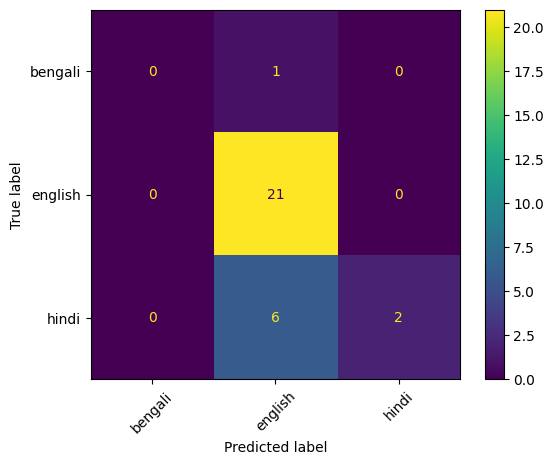

Model: Linear SVM
Target: Primary_Language

Cross Validation Scores:
[0.76666667 0.8        0.79310345 0.86206897 0.72413793]

Average CV Accuracy: 78.92%

Test Accuracy: 86.67%

Classification Report:

              precision    recall  f1-score   support

     bengali       0.00      0.00      0.00         1
     english       0.84      1.00      0.91        21
       hindi       1.00      0.62      0.77         8

    accuracy                           0.87        30
   macro avg       0.61      0.54      0.56        30
weighted avg       0.85      0.87      0.84        30



/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


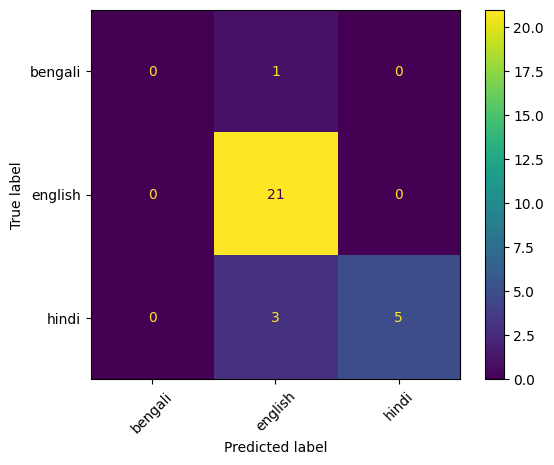

Model: Naive Bayes
Target: Primary_Language

Cross Validation Scores:
[0.73333333 0.7        0.68965517 0.68965517 0.68965517]

Average CV Accuracy: 70.05%

Test Accuracy: 73.33%

Classification Report:

              precision    recall  f1-score   support

     bengali       0.00      0.00      0.00         1
     english       0.72      1.00      0.84        21
       hindi       1.00      0.12      0.22         8

    accuracy                           0.73        30
   macro avg       0.57      0.38      0.35        30
weighted avg       0.77      0.73      0.65        30



/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


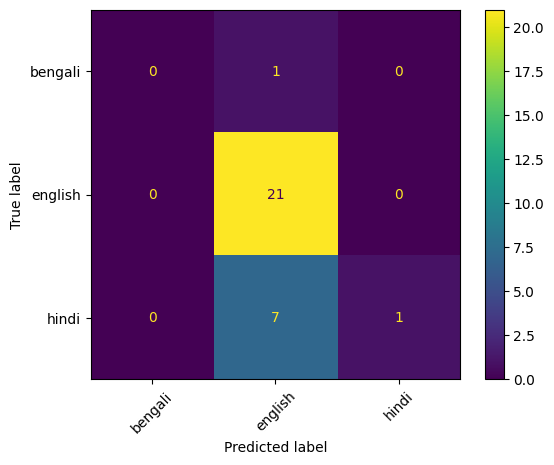

Model: Random Forest
Target: Primary_Language


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(



Cross Validation Scores:
[0.76666667 0.76666667 0.75862069 0.86206897 0.68965517]

Average CV Accuracy: 76.87%

Test Accuracy: 80.00%

Classification Report:

              precision    recall  f1-score   support

     bengali       0.00      0.00      0.00         1
     english       0.78      1.00      0.88        21
       hindi       1.00      0.38      0.55         8

    accuracy                           0.80        30
   macro avg       0.59      0.46      0.47        30
weighted avg       0.81      0.80      0.76        30



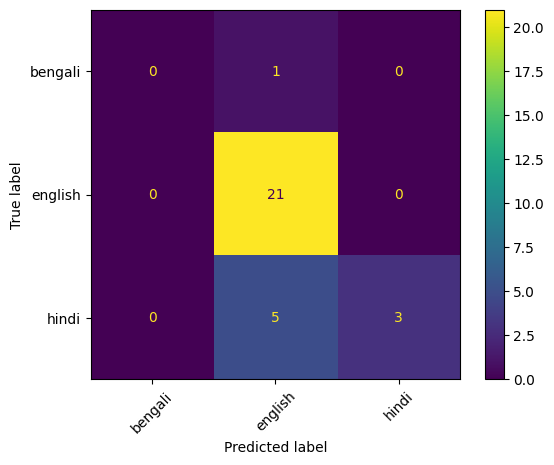

Model: Decision Tree
Target: Primary_Language

Cross Validation Scores:
[0.83333333 0.8        0.79310345 0.75862069 0.65517241]

Average CV Accuracy: 76.80%

Test Accuracy: 76.67%

Classification Report:

              precision    recall  f1-score   support

     bengali       0.00      0.00      0.00         1
     english       0.86      0.86      0.86        21
       hindi       0.71      0.62      0.67         8

    accuracy                           0.77        30
   macro avg       0.52      0.49      0.51        30
weighted avg       0.79      0.77      0.78        30



/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


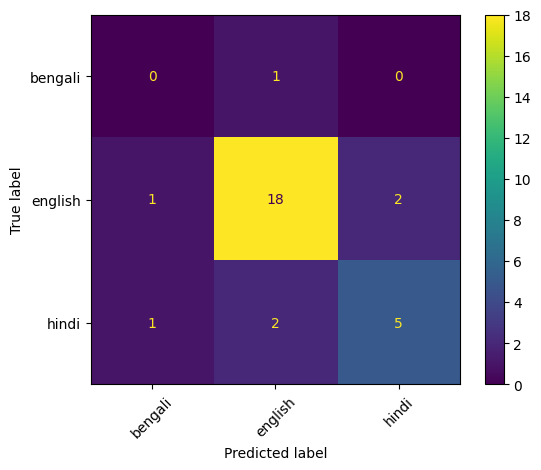

In [38]:
results_language = []

for name, model in models.items():

    cv_acc, test_acc = run_experiment(
        "Primary_Language",
        model,
        name
    )

    results_language.append([
        name,
        cv_acc,
        test_acc
    ])

In [39]:
language_df = pd.DataFrame(
    results_language,
    columns=[
        "Model",
        "CV Accuracy",
        "Test Accuracy"
    ]
)

language_df["CV Accuracy"] *= 100
language_df["Test Accuracy"] *= 100

language_df.sort_values(
    by="CV Accuracy",
    ascending=False
)

,Model,CV Accuracy,Test Accuracy
1,Linear SVM,78.919540,86.666667
3,Random Forest,76.873563,80.000000
4,Decision Tree,76.804598,76.666667
0,Logistic Regression,72.804598,76.666667
2,Naive Bayes,70.045977,73.333333


Model: Logistic Regression
Target: Production

Cross Validation Scores:
[0.63333333 0.63333333 0.65517241 0.65517241 0.62068966]

Average CV Accuracy: 63.95%

Test Accuracy: 60.00%

Classification Report:

                 precision    recall  f1-score   support

archive_footage       0.00      0.00      0.00         3
   field-report       0.00      0.00      0.00         8
studio_produced       0.62      0.95      0.75        19

       accuracy                           0.60        30
      macro avg       0.21      0.32      0.25        30
   weighted avg       0.39      0.60      0.47        30



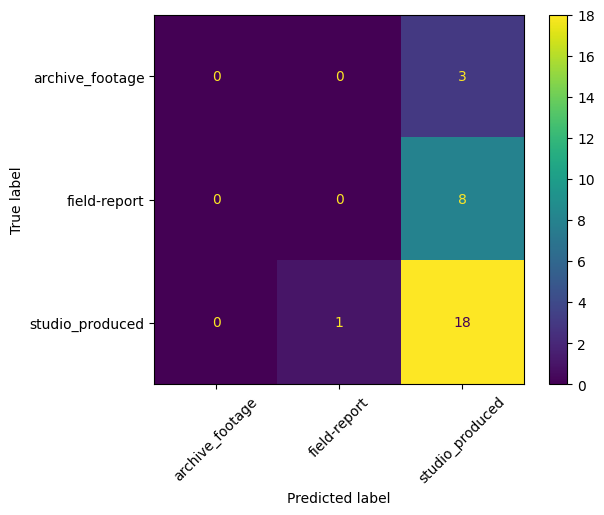

Model: Linear SVM
Target: Production

Cross Validation Scores:
[0.7        0.7        0.62068966 0.5862069  0.65517241]

Average CV Accuracy: 65.24%

Test Accuracy: 60.00%

Classification Report:

                 precision    recall  f1-score   support

archive_footage       1.00      0.33      0.50         3
   field-report       0.25      0.12      0.17         8
studio_produced       0.64      0.84      0.73        19

       accuracy                           0.60        30
      macro avg       0.63      0.43      0.46        30
   weighted avg       0.57      0.60      0.56        30



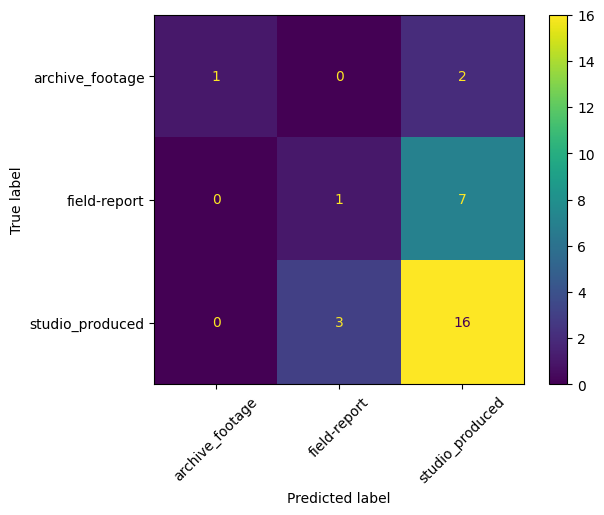

Model: Naive Bayes
Target: Production

Cross Validation Scores:
[0.63333333 0.63333333 0.65517241 0.65517241 0.65517241]

Average CV Accuracy: 64.64%

Test Accuracy: 63.33%

Classification Report:

                 precision    recall  f1-score   support

archive_footage       0.00      0.00      0.00         3
   field-report       0.00      0.00      0.00         8
studio_produced       0.63      1.00      0.78        19

       accuracy                           0.63        30
      macro avg       0.21      0.33      0.26        30
   weighted avg       0.40      0.63      0.49        30



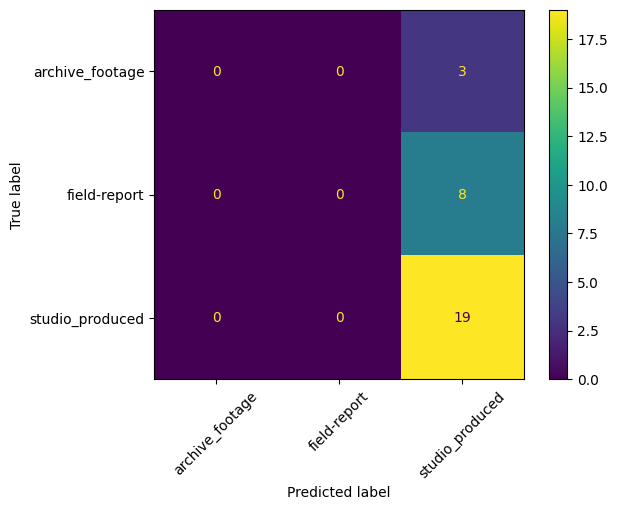

Model: Random Forest
Target: Production

Cross Validation Scores:
[0.63333333 0.63333333 0.62068966 0.65517241 0.68965517]

Average CV Accuracy: 64.64%

Test Accuracy: 63.33%

Classification Report:

                 precision    recall  f1-score   support

archive_footage       1.00      0.33      0.50         3
   field-report       0.33      0.12      0.18         8
studio_produced       0.65      0.89      0.76        19

       accuracy                           0.63        30
      macro avg       0.66      0.45      0.48        30
   weighted avg       0.60      0.63      0.58        30



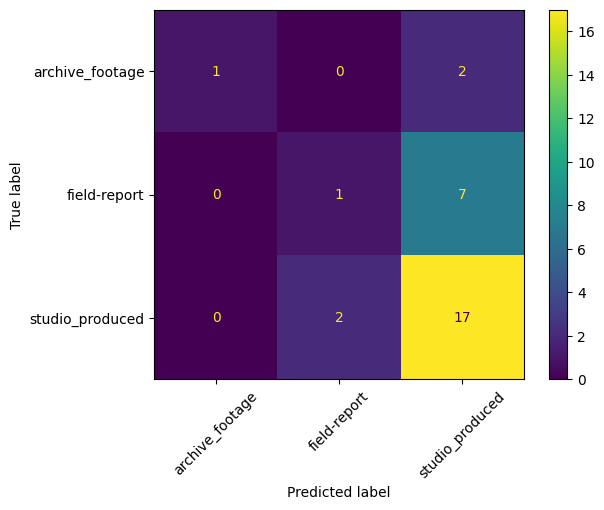

Model: Decision Tree
Target: Production

Cross Validation Scores:
[0.46666667 0.66666667 0.48275862 0.55172414 0.44827586]

Average CV Accuracy: 52.32%

Test Accuracy: 60.00%

Classification Report:

                 precision    recall  f1-score   support

archive_footage       0.33      0.33      0.33         3
   field-report       0.50      0.38      0.43         8
studio_produced       0.67      0.74      0.70        19

       accuracy                           0.60        30
      macro avg       0.50      0.48      0.49        30
   weighted avg       0.59      0.60      0.59        30



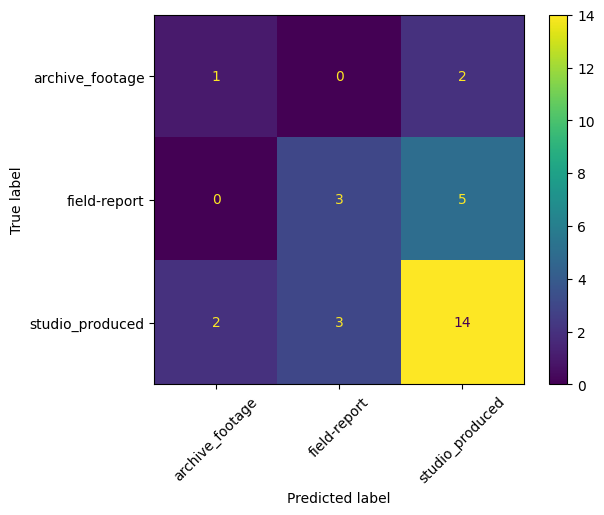

In [40]:
results_production = []

for name, model in models.items():

    cv_acc, test_acc = run_experiment(
        "Production",
        model,
        name
    )

    results_production.append([
        name,
        cv_acc,
        test_acc
    ])

In [41]:
production_df = pd.DataFrame(
    results_production,
    columns=[
        "Model",
        "CV Accuracy",
        "Test Accuracy"
    ]
)

production_df["CV Accuracy"] *= 100
production_df["Test Accuracy"] *= 100

production_df.sort_values(
    by="CV Accuracy",
    ascending=False)

,Model,CV Accuracy,Test Accuracy
1,Linear SVM,65.241379,60.000000
3,Random Forest,64.643678,63.333333
2,Naive Bayes,64.643678,63.333333
0,Logistic Regression,63.954023,60.000000
4,Decision Tree,52.321839,60.000000


In [42]:
comparison = pd.DataFrame({
    "Model": results_df["Model"],
    "Geography": results_df["CV Accuracy"],
    "Language": language_df["CV Accuracy"],
    "Production": production_df["CV Accuracy"]
})

comparison["Average"] = comparison[
    ["Geography", "Language", "Production"]
].mean(axis=1)

comparison = comparison.sort_values(
    by="Average",
    ascending=False
)

comparison

,Model,Geography,Language,Production,Average
1,Linear SVM,81.678161,78.919540,65.241379,75.279693
3,Random Forest,77.034483,76.873563,64.643678,72.850575
0,Logistic Regression,79.655172,72.804598,63.954023,72.137931
2,Naive Bayes,78.275862,70.045977,64.643678,70.988506
4,Decision Tree,53.793103,76.804598,52.321839,60.973180


In [43]:
print("Total videos:", len(dataset))

print("Number of Content Format classes:",
      dataset["Content_Format"].nunique())

print("\nDistribution:\n")

print(dataset["Content_Format"].value_counts())

Total videos: 147
Number of Content Format classes: 13

Distribution:

Content_Format
explainer           25
news_bulletin       25
interview           15
press_conference    13
breaking_news       13
fact_check          12
analysis            11
panel_discussion     9
documentary          8
debate               6
podcast_clip         6
reaction_video       2
vlog                 2
Name: count, dtype: int64


In [44]:
print("20% Test Set =", int(0.2*len(dataset)))

20% Test Set = 29


In [45]:
dataset["Source_Type"].value_counts()

,count
Source_Type,
mainstream_media,110
independent_creator,32
citizen_journalism,5


# Video Prediction

In [46]:
from sklearn.base import clone

# Replace these with the actual best models from your comparison results.
best_models = {
    "Geography": clone(models["Linear SVM"]),
    "Primary_Language": clone(models["Linear SVM"]),
    "Production": clone(models["Linear SVM"])
}

trained_models = {}

for target, model in best_models.items():

    print(f"Training final model for {target}...")

    y = dataset[target]

    # Train final model on the complete 50-video dataset
    model.fit(X, y)

    trained_models[target] = model

print("\nFinal models trained successfully!")

Training final model for Geography...
Training final model for Primary_Language...
Training final model for Production...

Final models trained successfully!


In [47]:
def prepare_new_video(url):

    video_id = extract_video_id(url)

    if video_id is None:
        raise ValueError("Invalid YouTube URL.")

    metadata = get_video_metadata(video_id)

    if metadata is None:
        raise ValueError("Could not retrieve metadata for this video.")

    title = metadata.get("title") or ""
    description = metadata.get("description") or ""
    tags = metadata.get("tags") or ""
    channel = metadata.get("channel") or ""

    combined_text = (
        title + " " +
        description + " " +
        tags + " " +
        channel
    )

    return metadata, combined_text

In [48]:
def predict_video(url):

    print("=" * 60)
    print("NEWS VIDEO METADATA CLASSIFIER")
    print("=" * 60)

    # 1. Extract metadata
    metadata, combined_text = prepare_new_video(url)

    print("\nVIDEO INFORMATION")
    print("-" * 60)

    print("Title:", metadata["title"])
    print("Channel:", metadata["channel"])
    print("Duration:", metadata["duration"])

    # 2. Convert text using EXISTING TF-IDF vectorizer
    new_X = vectorizer.transform([combined_text])

    print("\nPREDICTIONS")
    print("-" * 60)

    # 3. Predict every successfully trained target
    predictions = {}

    for target, model in trained_models.items():

        prediction = model.predict(new_X)[0]

        predictions[target] = prediction

        print(f"{target}: {prediction}")

    return predictions

In [49]:
test_url = input("Enter YouTube URL: ")

predictions = predict_video(test_url)

Enter YouTube URL: https://www.youtube.com/live/NIk-rPc2D5Y?si=G8i_MV0AJklLjpGw
NEWS VIDEO METADATA CLASSIFIER

VIDEO INFORMATION
------------------------------------------------------------
Title: LIVE This Morning: Bombay HC Transfers Disha Salian Case to CBI, Orders FIR Registration
Channel: Republic World
Duration: PT6H16S

PREDICTIONS
------------------------------------------------------------
Geography: india-national
Primary_Language: english
Production: studio_produced


In [50]:
test_url = input("Enter YouTube URL: ")

predictions = predict_video(test_url)

Enter YouTube URL: https://youtu.be/pmU0uL76bGo?si=XyHRgHoWHmForZx-
NEWS VIDEO METADATA CLASSIFIER

VIDEO INFORMATION
------------------------------------------------------------
Title: এটিএন বাংলার সকাল ৭ টার সংবাদ । ০২.০৯.২০২৬ । Today News | Ajker News | BD News | ATN Bangla News
Channel: ATN Bangla News
Duration: PT25M42S

PREDICTIONS
------------------------------------------------------------
Geography: bangladesh
Primary_Language: bengali
Production: studio_produced


In [51]:
test_url = input("Enter YouTube URL: ")

predictions = predict_video(test_url)

Enter YouTube URL: https://youtu.be/6YPFvedtABs?si=TjYSy5QKBlYy0m6Q
NEWS VIDEO METADATA CLASSIFIER

VIDEO INFORMATION
------------------------------------------------------------
Title: US-China Tensions Simmer at G20 Meeting | The China Show | 9/2/2026
Channel: Bloomberg Television
Duration: PT1H31M57S

PREDICTIONS
------------------------------------------------------------
Geography: global
Primary_Language: english
Production: studio_produced


# MLP Evaluation Across All Target Labels

In [52]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [53]:
from sklearn.neural_network import MLPClassifier

mlp_template = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=0.001,
    batch_size=8,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=False,
    random_state=42
)

In [54]:
def evaluate_mlp_target(target_column, max_folds=5):

    print("\n" + "=" * 70)
    print(f"MLP TARGET: {target_column}")
    print("=" * 70)

    y = dataset[target_column].astype(str)

    counts = y.value_counts()
    n_classes = y.nunique()
    min_class_count = counts.min()

    print("\nClass Distribution:")
    print(counts)

    print("\nTotal Samples:", len(y))
    print("Number of Classes:", n_classes)
    print("Smallest Class Size:", min_class_count)

    # Stratified CV is impossible with singleton classes.
    if min_class_count < 2:

        print("\nSTATUS: NOT RELIABLY EVALUABLE")
        print(
            "Reason: At least one class contains only one sample, "
            "so stratified cross-validation cannot be performed."
        )

        return {
            "Target": target_column,
            "Classes": n_classes,
            "Min Class Size": min_class_count,
            "CV Folds": np.nan,
            "Accuracy": np.nan,
            "Macro Precision": np.nan,
            "Macro Recall": np.nan,
            "Macro F1": np.nan,
            "Weighted F1": np.nan,
            "Status": "Not evaluable: singleton class"
        }

    # Automatically choose valid fold count.
    n_splits = min(max_folds, min_class_count)

    print(f"\nUsing {n_splits}-Fold Stratified Cross-Validation")

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    model = clone(mlp_template)

    # Every prediction is made for a sample that was excluded
    # from that fold's training data.
    y_pred = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method="predict"
    )

    accuracy = accuracy_score(y, y_pred)

    macro_precision = precision_score(
        y,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\nAccuracy:", round(accuracy * 100, 2), "%")
    print("Macro Precision:", round(macro_precision, 4))
    print("Macro Recall:", round(macro_recall, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))

    print("\nClassification Report:\n")

    print(
        classification_report(
            y,
            y_pred,
            zero_division=0
        )
    )

    labels = sorted(y.unique())

    cm = confusion_matrix(
        y,
        y_pred,
        labels=labels
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    fig, ax = plt.subplots(figsize=(10, 8))

    disp.plot(
        ax=ax,
        xticks_rotation=45,
        colorbar=False
    )

    plt.title(f"MLP Confusion Matrix — {target_column}")
    plt.tight_layout()
    plt.show()

    return {
        "Target": target_column,
        "Classes": n_classes,
        "Min Class Size": min_class_count,
        "CV Folds": n_splits,
        "Accuracy": accuracy * 100,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Status": "Evaluated"
    }


MLP TARGET: Content_Format

Class Distribution:
Content_Format
explainer           25
news_bulletin       25
interview           15
press_conference    13
breaking_news       13
fact_check          12
analysis            11
panel_discussion     9
documentary          8
debate               6
podcast_clip         6
reaction_video       2
vlog                 2
Name: count, dtype: int64

Total Samples: 147
Number of Classes: 13
Smallest Class Size: 2

Using 2-Fold Stratified Cross-Validation

Accuracy: 27.21 %
Macro Precision: 0.2726
Macro Recall: 0.2126
Macro F1: 0.2231
Weighted F1: 0.2546

Classification Report:

                  precision    recall  f1-score   support

        analysis       0.00      0.00      0.00        11
   breaking_news       0.33      0.31      0.32        13
          debate       0.00      0.00      0.00         6
     documentary       1.00      0.38      0.55         8
       explainer       0.22      0.48      0.30        25
      fact_check       0.00  

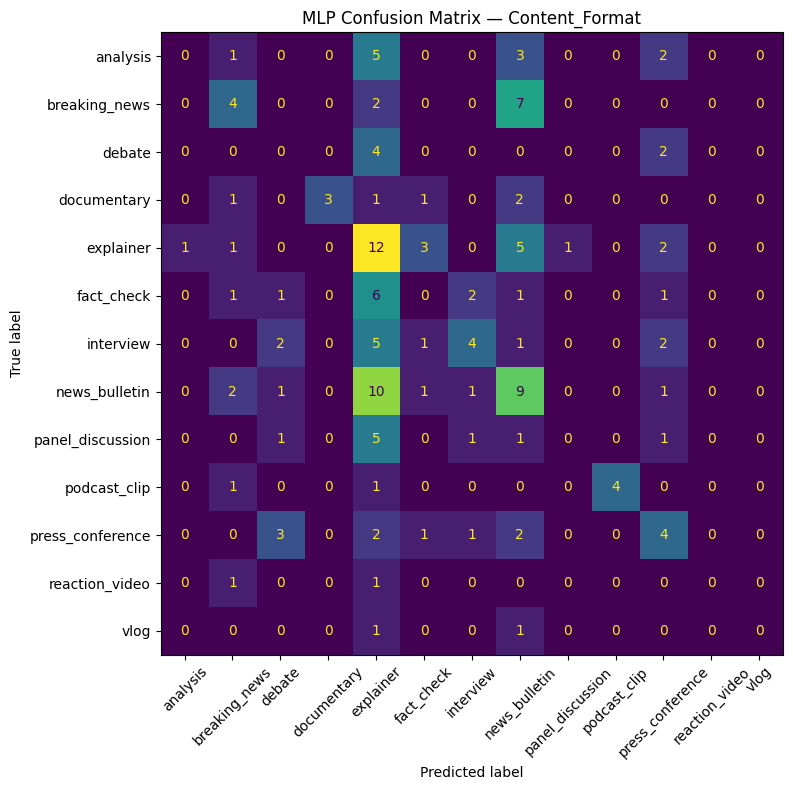


MLP TARGET: Source_Type

Class Distribution:
Source_Type
mainstream_media       110
independent_creator     32
citizen_journalism       5
Name: count, dtype: int64

Total Samples: 147
Number of Classes: 3
Smallest Class Size: 5

Using 5-Fold Stratified Cross-Validation

Accuracy: 84.35 %
Macro Precision: 0.5758
Macro Recall: 0.4866
Macro F1: 0.5081
Weighted F1: 0.8158

Classification Report:

                     precision    recall  f1-score   support

 citizen_journalism       0.00      0.00      0.00         5
independent_creator       0.88      0.47      0.61        32
   mainstream_media       0.84      0.99      0.91       110

           accuracy                           0.84       147
          macro avg       0.58      0.49      0.51       147
       weighted avg       0.82      0.84      0.82       147



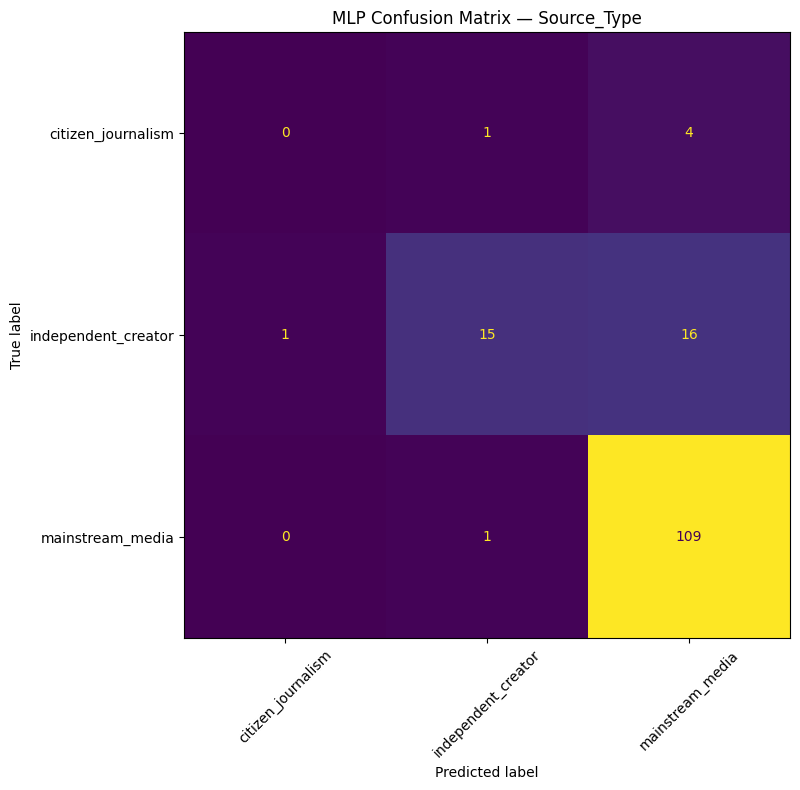


MLP TARGET: Primary_Language

Class Distribution:
Primary_Language
english    102
hindi       42
bengali      3
Name: count, dtype: int64

Total Samples: 147
Number of Classes: 3
Smallest Class Size: 3

Using 3-Fold Stratified Cross-Validation

Accuracy: 82.99 %
Macro Precision: 0.5541
Macro Recall: 0.5154
Macro F1: 0.5268
Weighted F1: 0.8131

Classification Report:

              precision    recall  f1-score   support

     bengali       0.00      0.00      0.00         3
     english       0.83      0.95      0.89       102
       hindi       0.83      0.60      0.69        42

    accuracy                           0.83       147
   macro avg       0.55      0.52      0.53       147
weighted avg       0.81      0.83      0.81       147



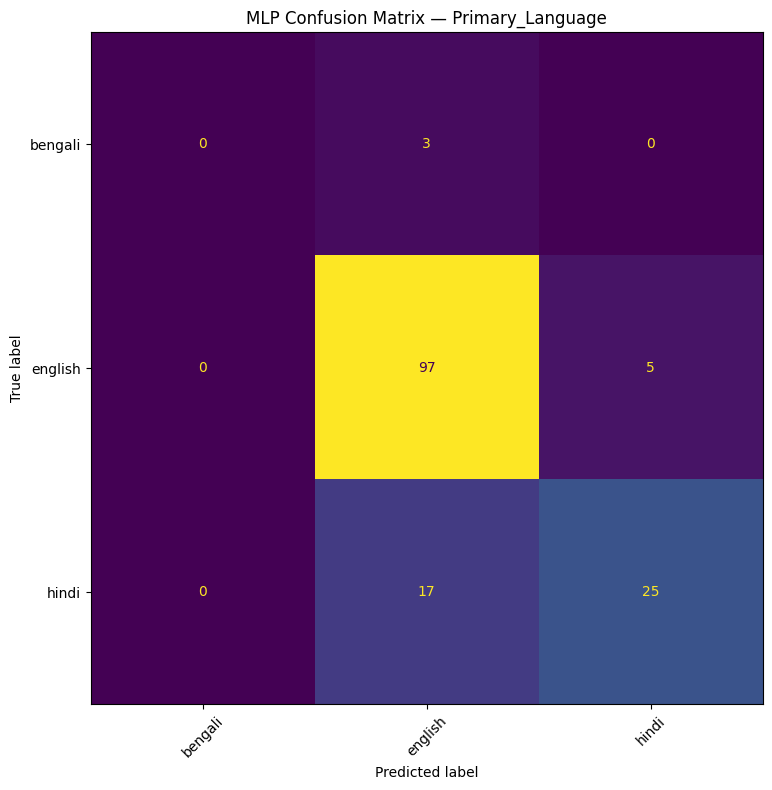


MLP TARGET: Geography

Class Distribution:
Geography
india-national         74
global                 61
south_asia_regional     8
bangladesh              4
Name: count, dtype: int64

Total Samples: 147
Number of Classes: 4
Smallest Class Size: 4

Using 4-Fold Stratified Cross-Validation

Accuracy: 78.23 %
Macro Precision: 0.4787
Macro Recall: 0.4545
Macro F1: 0.4538
Weighted F1: 0.7606

Classification Report:

                     precision    recall  f1-score   support

         bangladesh       0.00      0.00      0.00         4
             global       0.76      0.87      0.81        61
     india-national       0.82      0.82      0.82        74
south_asia_regional       0.33      0.12      0.18         8

           accuracy                           0.78       147
          macro avg       0.48      0.45      0.45       147
       weighted avg       0.75      0.78      0.76       147



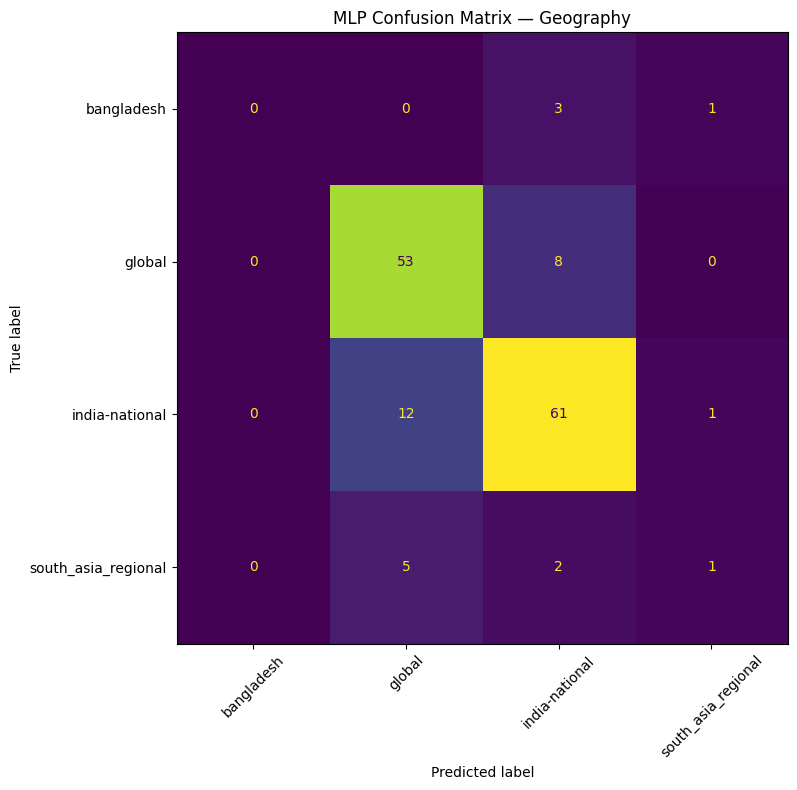


MLP TARGET: Production

Class Distribution:
Production
studio_produced    95
field-report       39
archive_footage    13
Name: count, dtype: int64

Total Samples: 147
Number of Classes: 3
Smallest Class Size: 13

Using 5-Fold Stratified Cross-Validation

Accuracy: 65.31 %
Macro Precision: 0.4586
Macro Recall: 0.4245
Macro F1: 0.4291
Weighted F1: 0.6213

Classification Report:

                 precision    recall  f1-score   support

archive_footage       0.14      0.08      0.10        13
   field-report       0.52      0.33      0.41        39
studio_produced       0.71      0.86      0.78        95

       accuracy                           0.65       147
      macro avg       0.46      0.42      0.43       147
   weighted avg       0.61      0.65      0.62       147



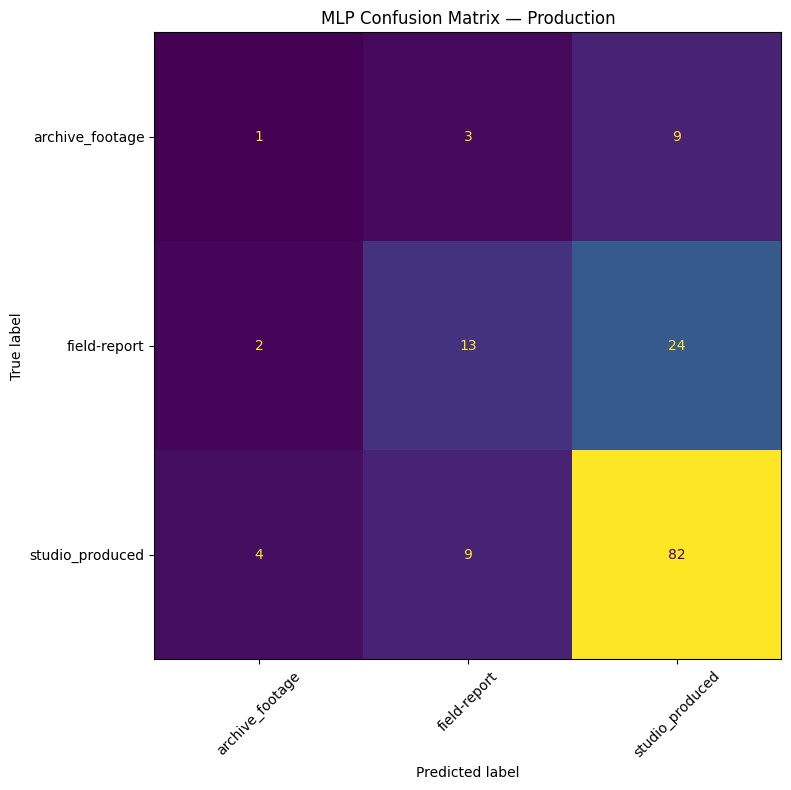

In [55]:
targets = [
    "Content_Format",
    "Source_Type",
    "Primary_Language",
    "Geography",
    "Production"
]

mlp_results = []

for target in targets:

    result = evaluate_mlp_target(target)

    mlp_results.append(result)

In [56]:
mlp_results_df = pd.DataFrame(mlp_results)

mlp_results_df

,Target,Classes,Min Class Size,CV Folds,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Status
0,Content_Format,13,2,2,27.210884,0.272606,0.212594,0.223099,0.254644,Evaluated
1,Source_Type,3,5,5,84.353741,0.575771,0.486553,0.508126,0.815827,Evaluated
2,Primary_Language,3,3,3,82.993197,0.554131,0.515406,0.526763,0.813080,Evaluated
3,Geography,4,4,4,78.231293,0.478700,0.454544,0.453826,0.760635,Evaluated
4,Production,3,13,5,65.306122,0.458634,0.424471,0.429067,0.621321,Evaluated


In [57]:
display_columns = [
    "Target",
    "Classes",
    "Min Class Size",
    "CV Folds",
    "Accuracy",
    "Macro F1",
    "Weighted F1",
    "Status"
]

mlp_results_df[display_columns]

,Target,Classes,Min Class Size,CV Folds,Accuracy,Macro F1,Weighted F1,Status
0,Content_Format,13,2,2,27.210884,0.223099,0.254644,Evaluated
1,Source_Type,3,5,5,84.353741,0.508126,0.815827,Evaluated
2,Primary_Language,3,3,3,82.993197,0.526763,0.813080,Evaluated
3,Geography,4,4,4,78.231293,0.453826,0.760635,Evaluated
4,Production,3,13,5,65.306122,0.429067,0.621321,Evaluated


In [58]:
from sklearn.base import clone

targets = [
    "Content_Format",
    "Source_Type",
    "Primary_Language",
    "Geography",
    "Production"
]

final_mlp_models = {}

for target in targets:
    model = clone(mlp_template)
    model.fit(X, dataset[target].astype(str))
    final_mlp_models[target] = model

    print(f"Final MLP trained for: {target}")

print("\nAll final inference models trained successfully.")

Final MLP trained for: Content_Format
Final MLP trained for: Source_Type
Final MLP trained for: Primary_Language
Final MLP trained for: Geography
Final MLP trained for: Production

All final inference models trained successfully.


In [59]:
def predict_random_video(url):

    print("=" * 70)
    print("METADATA-BASED MLP NEWS VIDEO CLASSIFIER")
    print("=" * 70)

    # Extract video ID
    video_id = extract_video_id(url)

    if video_id is None:
        print("Invalid YouTube URL.")
        return None

    # Check whether the video is truly unseen
    training_ids = set(dataset["Video_ID"].astype(str))

    if video_id in training_ids:
        print("\nWARNING: This video is present in the training dataset.")
    else:
        print("\nUnseen video: not present in the training dataset.")

    # Retrieve metadata
    metadata = get_video_metadata(video_id)

    if metadata is None:
        print("Could not retrieve metadata.")
        return None

    title = metadata.get("title") or ""
    description = metadata.get("description") or ""
    tags = metadata.get("tags") or ""
    channel = metadata.get("channel") or ""

    if isinstance(tags, list):
        tags = " ".join(tags)

    # IMPORTANT: must match training feature construction
    combined_text = (
        title + " " +
        description + " " +
        tags + " " +
        channel
    )

    # Use the EXISTING fitted vectorizer
    new_X = vectorizer.transform([combined_text])

    print("\nVIDEO INFORMATION")
    print("-" * 70)
    print("Title:", title)
    print("Channel:", channel)

    print("\nMLP PREDICTIONS")
    print("-" * 70)

    predictions = {}

    for target, model in final_mlp_models.items():

        prediction = model.predict(new_X)[0]

        predictions[target] = prediction

        if target in ["Content_Format", "Source_Type"]:
            print(f"{target}: {prediction}  [LOW CONFIDENCE / LIMITED DATA]")
        else:
            print(f"{target}: {prediction}")

    return predictions

In [60]:
test_url = input("Enter a NEW YouTube URL: ")

predictions = predict_random_video(test_url)

Enter a NEW YouTube URL: https://www.youtube.com/live/W6DnWydb2gc?si=wTEPt5zkejWrShdG
METADATA-BASED MLP NEWS VIDEO CLASSIFIER

Unseen video: not present in the training dataset.

VIDEO INFORMATION
----------------------------------------------------------------------
Title: 24 Oras Livestream: September 1, 2026
Channel: GMA News

MLP PREDICTIONS
----------------------------------------------------------------------
Content_Format: explainer  [LOW CONFIDENCE / LIMITED DATA]
Source_Type: mainstream_media  [LOW CONFIDENCE / LIMITED DATA]
Primary_Language: english
Geography: india-national
Production: studio_produced
